In [1]:
# 1. Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля графиков (делает их красивее и профессиональнее)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6) # Размер графиков по умолчанию

# 2. Загрузка данных
# Убедись, что файл лежит в той же папке, что и notebook, или укажи полный путь
# Например: df = pd.read_csv('online_gaming_behavior_dataset.csv')
try:
    df = pd.read_csv('online_gaming_behavior_dataset.csv')
    print("Данные успешно загружены!")
except FileNotFoundError:
    print("Ошибка: Файл не найден. Проверь название файла и путь к нему.")

# 3. Быстрый взгляд на данные
print(f"Размер датасета: {df.shape}")
df.head()

Данные успешно загружены!
Размер датасета: (40034, 13)


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


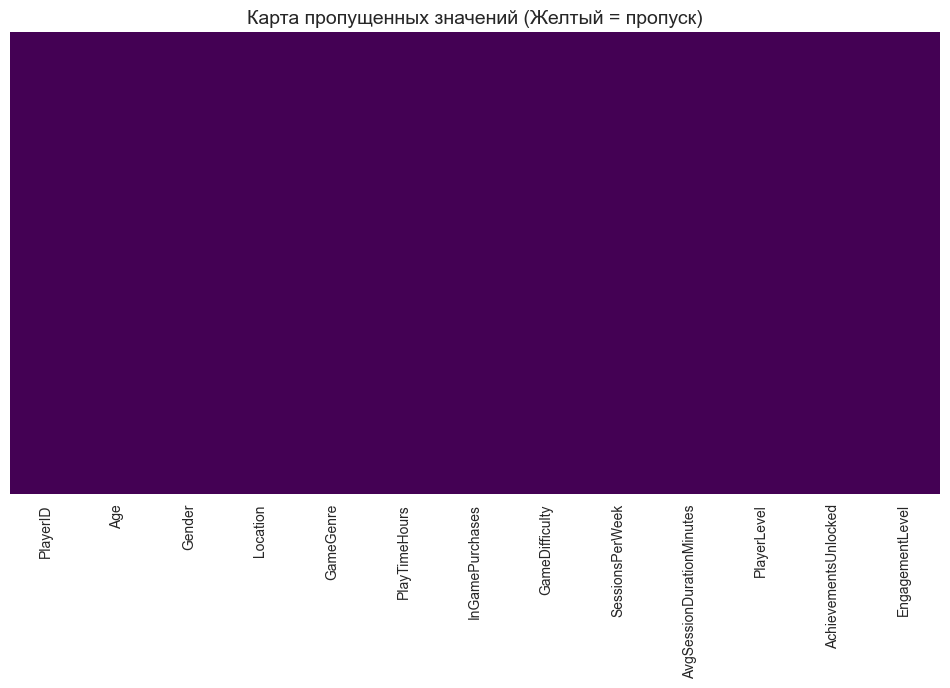

Количество пропусков по столбцам:
PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64


C:\Users\Shaim\AppData\Local\Temp\ipykernel_11692\3010715423.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_counts.index, y=unique_counts.values, palette='magma')


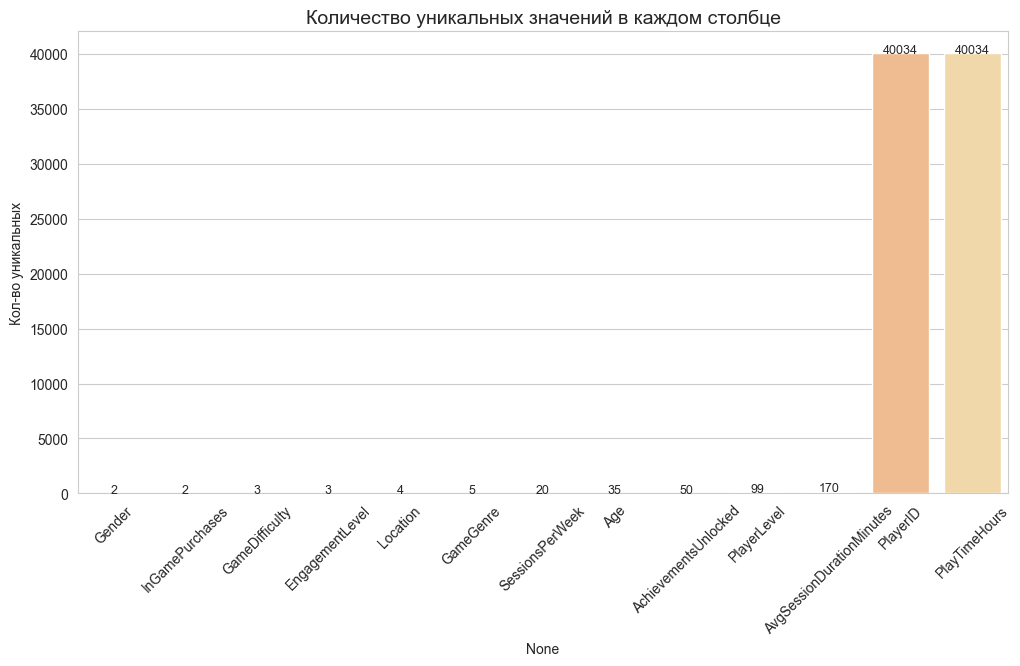

------------------------------
Типы данных:
PlayerID                       int64
Age                            int64
Gender                        object
Location                      object
GameGenre                     object
PlayTimeHours                float64
InGamePurchases                int64
GameDifficulty                object
SessionsPerWeek                int64
AvgSessionDurationMinutes      int64
PlayerLevel                    int64
AchievementsUnlocked           int64
EngagementLevel               object
dtype: object
------------------------------
Количество полных дубликатов строк: 0


In [2]:
# --- БЛОК ПРОВЕРКИ КАЧЕСТВА ДАННЫХ ---

# 1. Проверка на пропущенные значения (Визуализация)
plt.figure(figsize=(12, 6))
# Используем heatmap: желтые полоски покажут пропуски, фиолетовые - данные
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Карта пропущенных значений (Желтый = пропуск)', fontsize=14)
plt.show()

# Текстовый вывод пропусков
print("Количество пропусков по столбцам:")
print(df.isnull().sum())

# 2. Проверка количества уникальных значений (Визуализация)
unique_counts = df.nunique().sort_values()

plt.figure(figsize=(12, 6))
sns.barplot(x=unique_counts.index, y=unique_counts.values, palette='magma')
plt.xticks(rotation=45)
plt.title('Количество уникальных значений в каждом столбце', fontsize=14)
plt.ylabel('Кол-во уникальных')
# Добавим подписи значений над столбиками для наглядности
for i, v in enumerate(unique_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=9)
plt.show()

# 3. Общая информация и дубликаты
print("-" * 30)
print("Типы данных:")
print(df.dtypes)
print("-" * 30)
duplicates = df.duplicated().sum()
print(f"Количество полных дубликатов строк: {duplicates}")

C:\Users\Shaim\AppData\Local\Temp\ipykernel_11692\476677679.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='EngagementLevel', order=['Low', 'Medium', 'High'], palette='viridis')


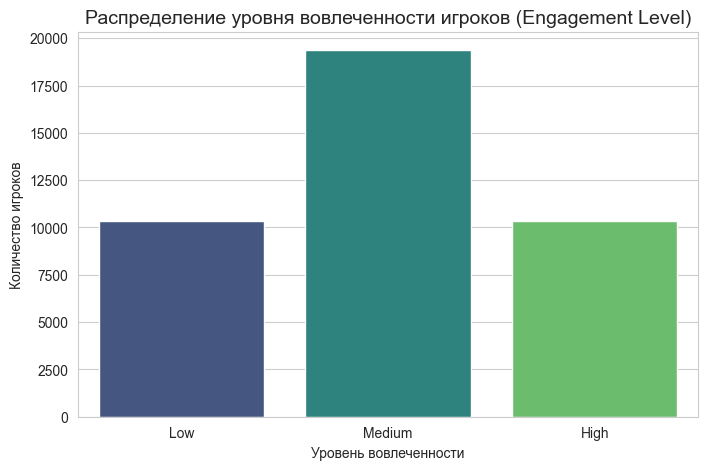

EngagementLevel
Medium    48.393865
High      25.818055
Low       25.788080
Name: proportion, dtype: float64


In [3]:
# Анализ целевой переменной
plt.figure(figsize=(8, 5))

# Считаем количество и строим график
sns.countplot(data=df, x='EngagementLevel', order=['Low', 'Medium', 'High'], palette='viridis')

plt.title('Распределение уровня вовлеченности игроков (Engagement Level)', fontsize=14)
plt.xlabel('Уровень вовлеченности')
plt.ylabel('Количество игроков')
plt.show()

# Точные цифры в процентах
print(df['EngagementLevel'].value_counts(normalize=True) * 100)

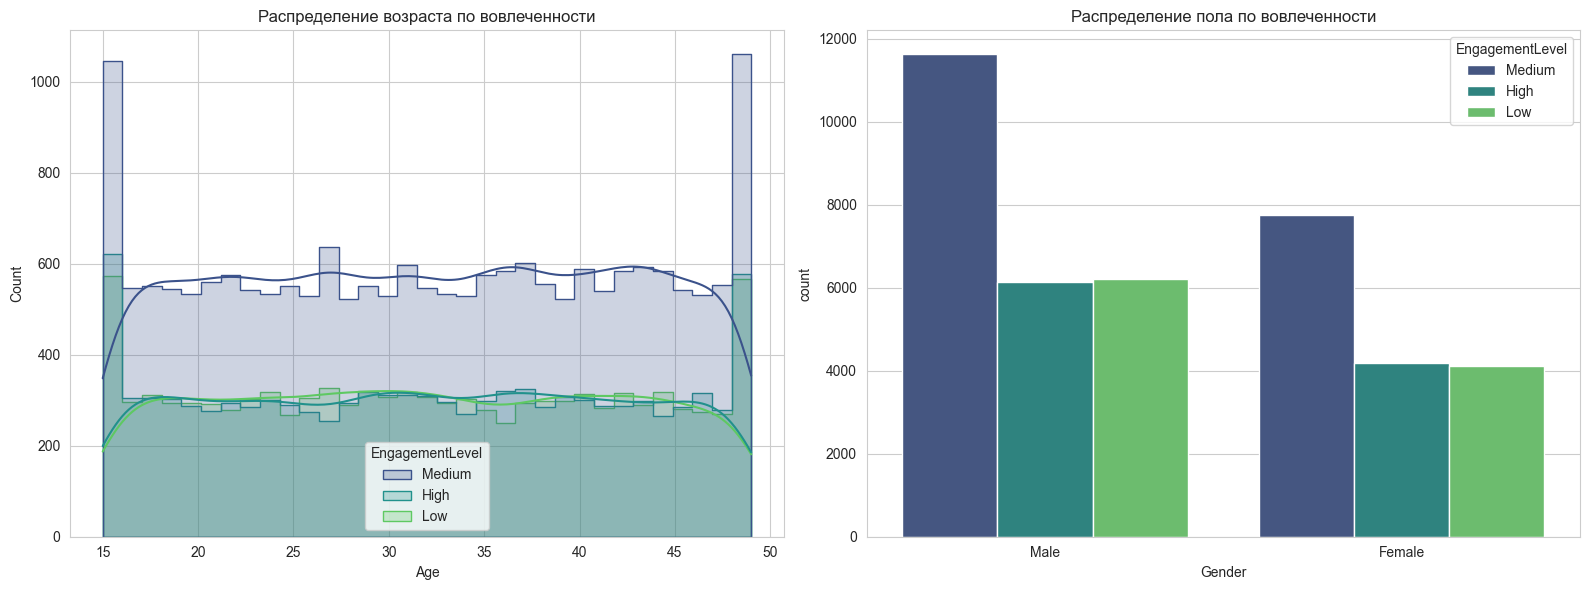

In [4]:
# Настройка сетки графиков: 1 строка, 2 колонки
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Распределение возраста
sns.histplot(data=df, x='Age', hue='EngagementLevel', kde=True, element="step", palette='viridis', ax=axes[0])
axes[0].set_title('Распределение возраста по вовлеченности')

# График 2: Пол
sns.countplot(data=df, x='Gender', hue='EngagementLevel', palette='viridis', ax=axes[1])
axes[1].set_title('Распределение пола по вовлеченности')

plt.tight_layout()
plt.show()

            PlayerCount  AvgPlayTime
GameGenre                           
Sports             8048    11.968329
Action             8039    12.164645
Strategy           8012    12.081855
Simulation         7983    11.898085
RPG                7952    12.008113


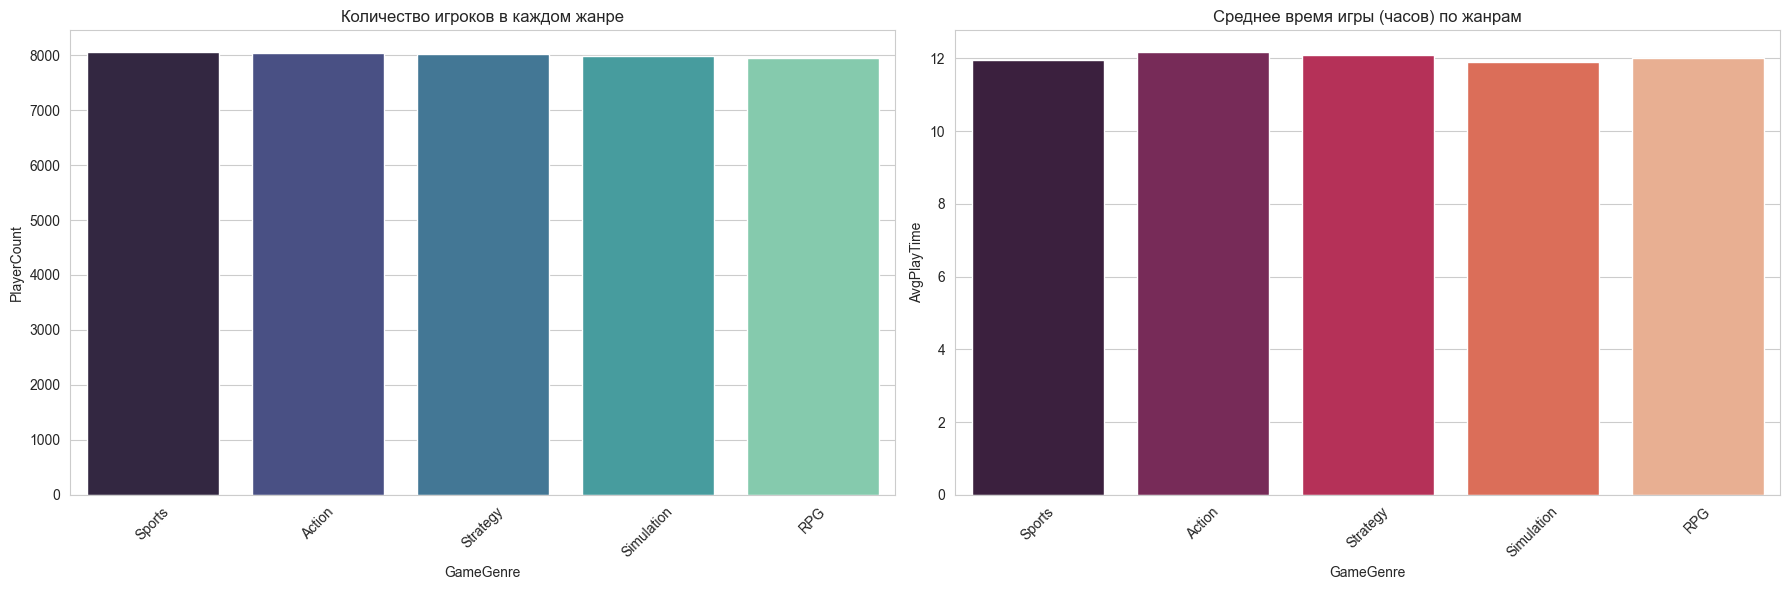

In [5]:
# Группируем данные по жанрам
genre_stats = df.groupby('GameGenre').agg({
    'PlayerID': 'count',           # Считаем количество игроков
    'PlayTimeHours': 'mean'        # Считаем среднее время игры
}).rename(columns={'PlayerID': 'PlayerCount', 'PlayTimeHours': 'AvgPlayTime'}).sort_values(by='PlayerCount', ascending=False)

print(genre_stats)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# График 1: Самые популярные жанры (по количеству людей)
sns.barplot(x=genre_stats.index, y=genre_stats['PlayerCount'], hue=genre_stats.index, palette='mako', ax=axes[0], legend=False)
axes[0].set_title('Количество игроков в каждом жанре')
axes[0].tick_params(axis='x', rotation=45)

# График 2: В каких жанрах сидят дольше всего?
sns.barplot(x=genre_stats.index, y=genre_stats['AvgPlayTime'], hue=genre_stats.index, palette='rocket', ax=axes[1], legend=False)
axes[1].set_title('Среднее время игры (часов) по жанрам')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

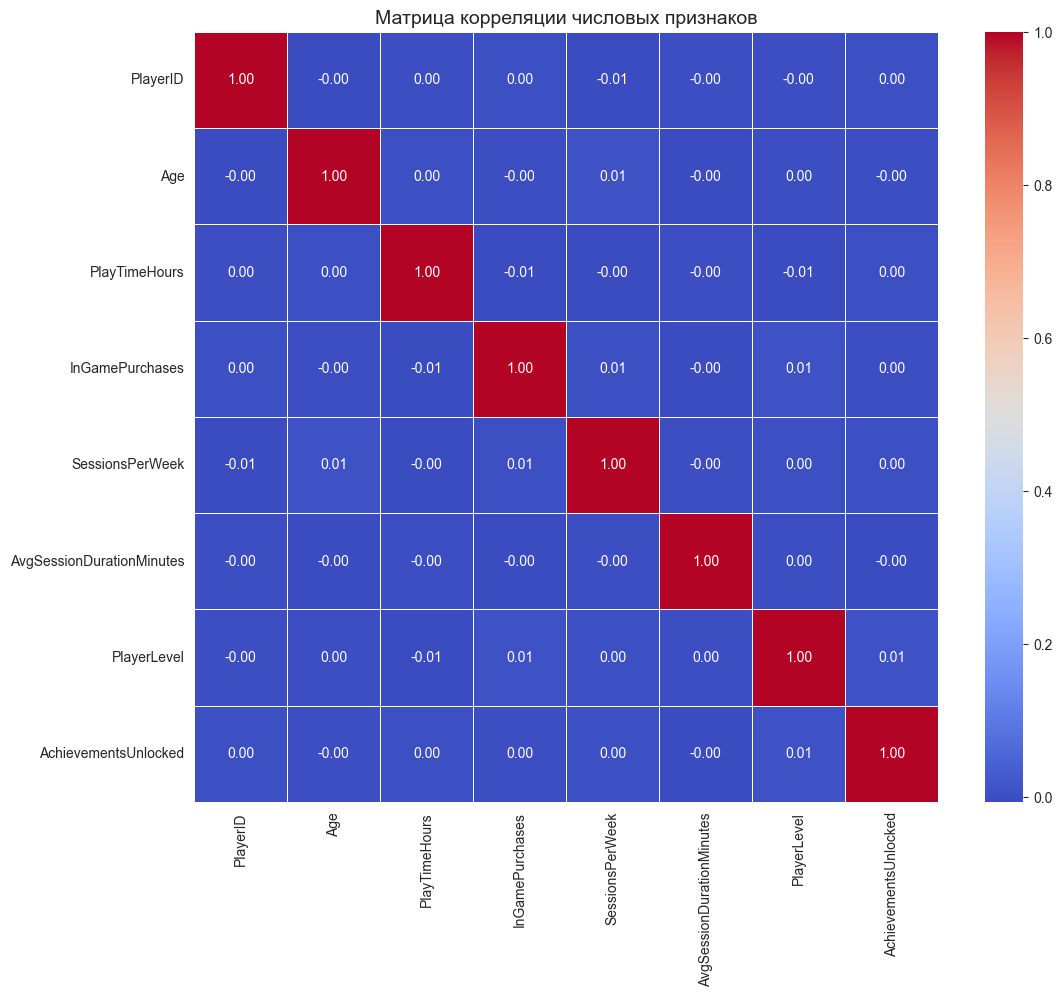

In [6]:
plt.figure(figsize=(12, 10))

# Выбираем только числовые колонки для корреляции
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Рисуем тепловую карту
# annot=True пишет цифры в клетках, fmt='.2f' оставляет 2 знака после запятой
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Матрица корреляции числовых признаков', fontsize=14)
plt.show()

C:\Users\Shaim\AppData\Local\Temp\ipykernel_11692\850957993.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='InGamePurchases', y='PlayTimeHours', palette='Set2', ax=axes[0])


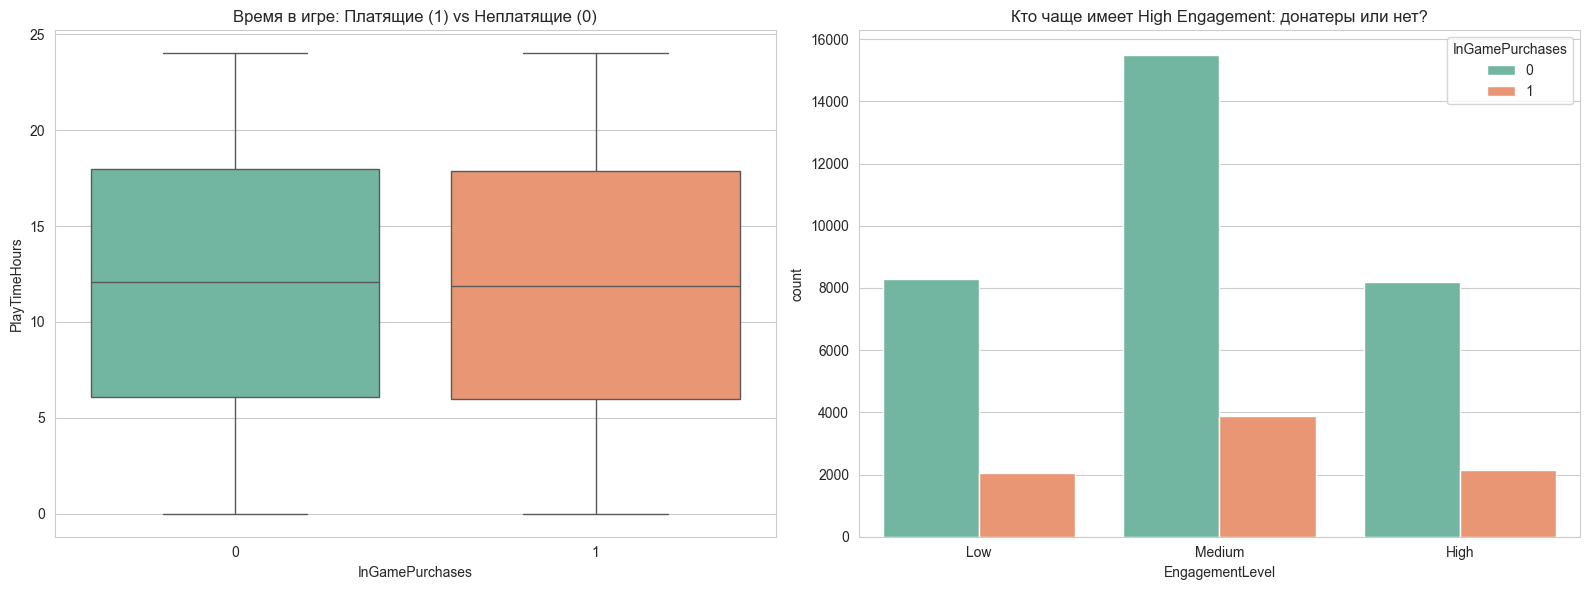

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Влияет ли донат на время в игре?
sns.boxplot(data=df, x='InGamePurchases', y='PlayTimeHours', palette='Set2', ax=axes[0])
axes[0].set_title('Время в игре: Платящие (1) vs Неплатящие (0)')

# График 2: Как донат распределен по уровням вовлеченности?
# Мы используем countplot с hue, чтобы разбить столбики
sns.countplot(data=df, x='EngagementLevel', hue='InGamePurchases', order=['Low', 'Medium', 'High'], palette='Set2', ax=axes[1])
axes[1].set_title('Кто чаще имеет High Engagement: донатеры или нет?')

plt.tight_layout()
plt.show()

C:\Users\Shaim\AppData\Local\Temp\ipykernel_11692\1494759085.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='GameDifficulty', y='AvgSessionDurationMinutes', order=difficulty_order, palette='muted')


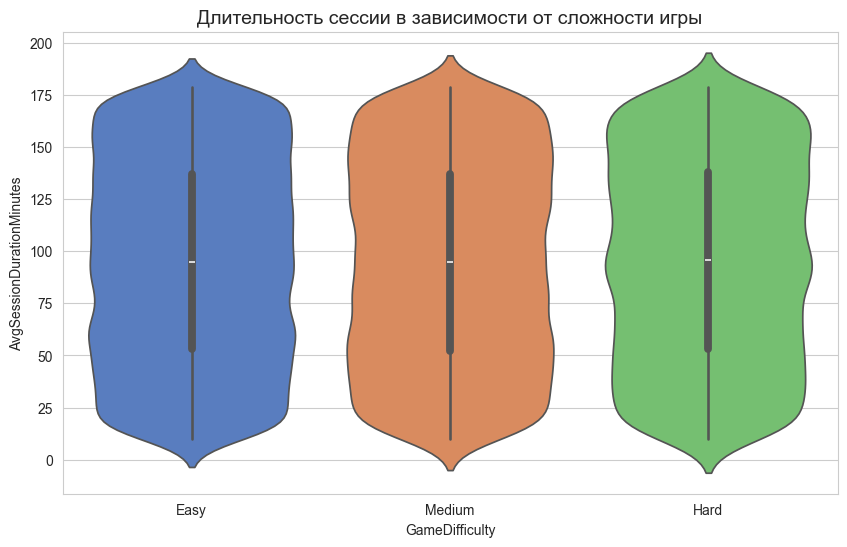

In [8]:
plt.figure(figsize=(10, 6))

# Порядок сортировки сложности важен для графика
difficulty_order = ['Easy', 'Medium', 'Hard']

# Используем Violin Plot - он показывает и среднее, и распределение ("пузатость" показывает, где больше всего людей)
sns.violinplot(data=df, x='GameDifficulty', y='AvgSessionDurationMinutes', order=difficulty_order, palette='muted')

plt.title('Длительность сессии в зависимости от сложности игры', fontsize=14)
plt.show()

C:\Users\Shaim\AppData\Local\Temp\ipykernel_11692\1883462474.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_eng.index, y=location_eng.values, palette='coolwarm')


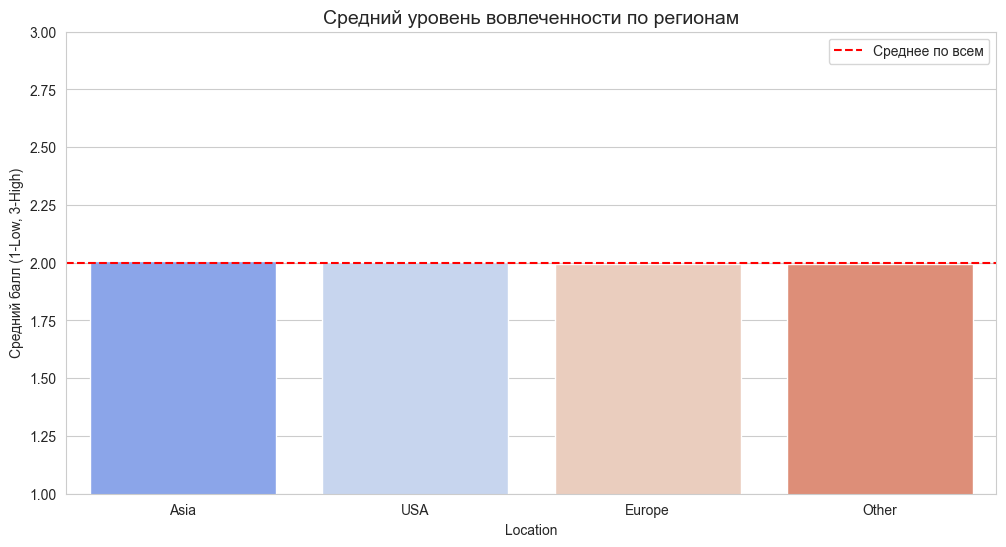

In [9]:
plt.figure(figsize=(12, 6))

# Считаем среднюю вовлеченность по локациям
# Для этого временно переведем EngagementLevel в числа: Low=1, Medium=2, High=3
df['Eng_Numeric'] = df['EngagementLevel'].map({'Low': 1, 'Medium': 2, 'High': 3})
location_eng = df.groupby('Location')['Eng_Numeric'].mean().sort_values(ascending=False)

sns.barplot(x=location_eng.index, y=location_eng.values, palette='coolwarm')
plt.axhline(df['Eng_Numeric'].mean(), color='red', linestyle='--', label='Среднее по всем')
plt.title('Средний уровень вовлеченности по регионам', fontsize=14)
plt.ylabel('Средний балл (1-Low, 3-High)')
plt.ylim(1, 3) # Чтобы лучше видеть разницу
plt.legend()
plt.show()

# Удалим временную колонку, чтобы не засорять данные
df.drop('Eng_Numeric', axis=1, inplace=True)

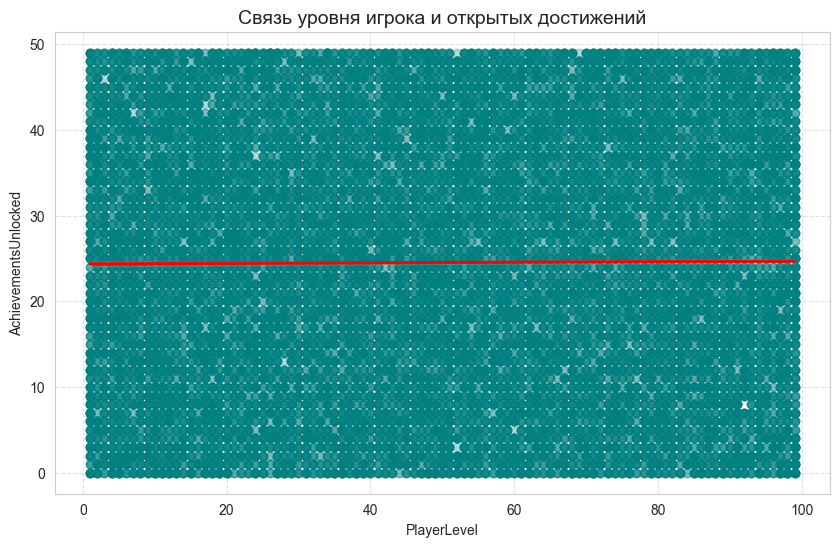

In [10]:
plt.figure(figsize=(10, 6))

# Построение диаграммы рассеяния с линией тренда
sns.regplot(data=df, x='PlayerLevel', y='AchievementsUnlocked', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})

plt.title('Связь уровня игрока и открытых достижений', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

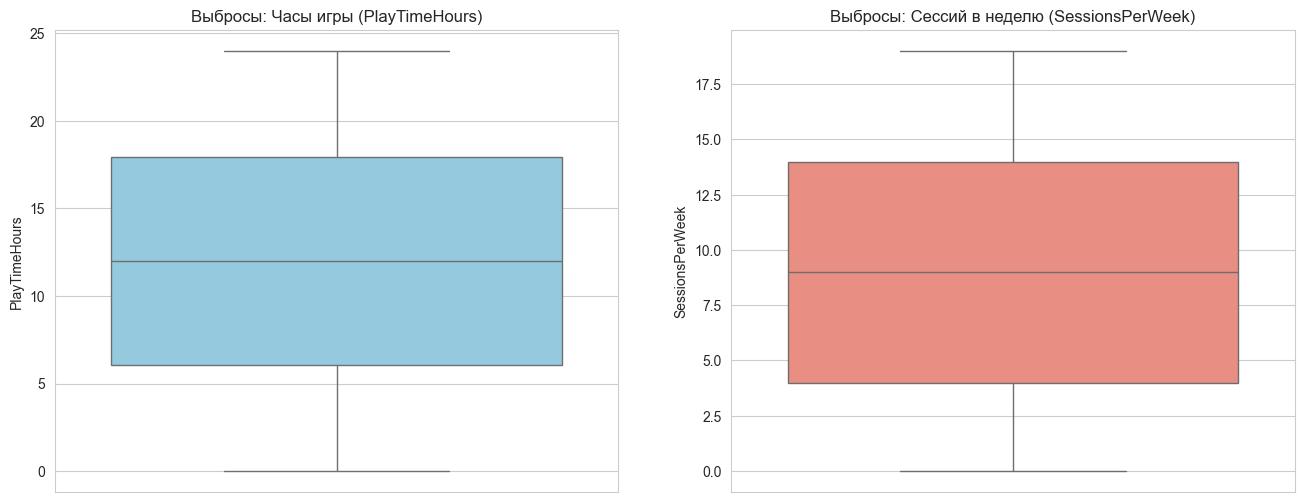

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Проверяем часы в неделю и количество сессий
sns.boxplot(y=df['PlayTimeHours'], color='skyblue', ax=axes[0])
axes[0].set_title('Выбросы: Часы игры (PlayTimeHours)')

sns.boxplot(y=df['SessionsPerWeek'], color='salmon', ax=axes[1])
axes[1].set_title('Выбросы: Сессий в неделю (SessionsPerWeek)')

plt.show()

=== ИТОГОВЫЕ ПРОДУКТОВЫЕ МЕТРИКИ ===
Conversion_Rate          :      20.09
ARPU                     :       2.01
ARPPU                    :      10.00
Avg_Weekly_Time_Mins     :     897.68
Stickiness_Proxy         :       1.35
Avg_Progression_Speed    :      49.31
Achievement_Density      :       1.28


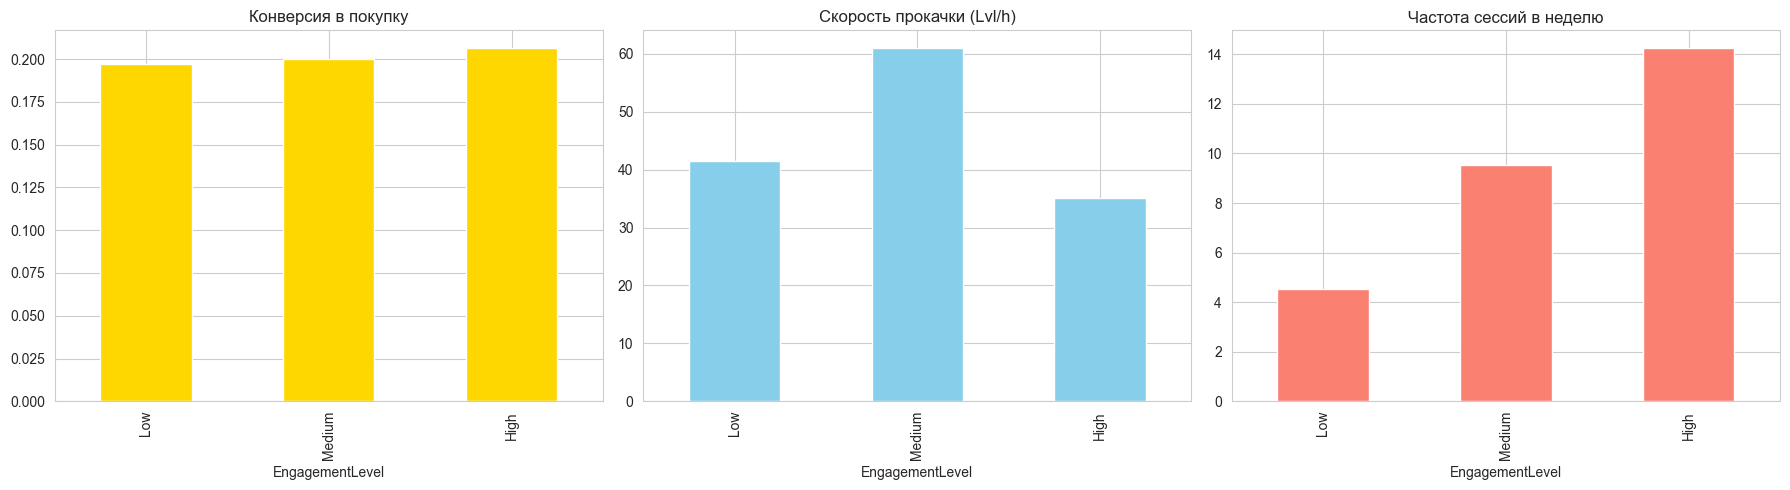

In [12]:
# Создаем словарь для хранения метрик
kpi = {}

# --- 1. МОНЕТИЗАЦИЯ (Monetization) ---
# Доля платящих игроков
kpi['Conversion_Rate'] = (df['InGamePurchases'].mean()) * 100

# Синтетический доход (предположим, средний чек $10)
avg_check = 10 
total_revenue = df['InGamePurchases'].sum() * avg_check
kpi['ARPU'] = total_revenue / len(df) # Average Revenue Per User
kpi['ARPPU'] = total_revenue / df['InGamePurchases'].sum() # Average Revenue Per Paying User

# --- 2. ВОВЛЕЧЕННОСТЬ (Engagement) ---
# Средняя интенсивность (сессий в неделю на время сессии)
kpi['Avg_Weekly_Time_Mins'] = (df['SessionsPerWeek'] * df['AvgSessionDurationMinutes']).mean()
kpi['Stickiness_Proxy'] = df['SessionsPerWeek'].mean() / 7 # Насколько часто заходят в неделю

# --- 3. ПРОГРЕССИЯ И СЛОЖНОСТЬ ---
# Коэффициент сложности (уровень за час игры)
df['Level_Per_Hour'] = df['PlayerLevel'] / df['PlayTimeHours'].replace(0, 1)
kpi['Avg_Progression_Speed'] = df['Level_Per_Hour'].mean()

# Отношение ачивок к уровню (эффективность контента)
kpi['Achievement_Density'] = (df['AchievementsUnlocked'] / df['PlayerLevel'].replace(0, 1)).mean()

# --- ВЫВОД РЕЗУЛЬТАТОВ ---
print("=== ИТОГОВЫЕ ПРОДУКТОВЫЕ МЕТРИКИ ===")
for key, value in kpi.items():
    print(f"{key:25}: {value:10.2f}")

# Визуализация метрик по сегментам вовлеченности
metrics_by_engagement = df.groupby('EngagementLevel').agg({
    'InGamePurchases': 'mean',
    'Level_Per_Hour': 'mean',
    'SessionsPerWeek': 'mean'
}).reindex(['Low', 'Medium', 'High'])

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
metrics_by_engagement['InGamePurchases'].plot(kind='bar', ax=ax[0], color='gold', title='Конверсия в покупку')
metrics_by_engagement['Level_Per_Hour'].plot(kind='bar', ax=ax[1], color='skyblue', title='Скорость прокачки (Lvl/h)')
metrics_by_engagement['SessionsPerWeek'].plot(kind='bar', ax=ax[2], color='salmon', title='Частота сессий в неделю')
plt.tight_layout()
plt.show()

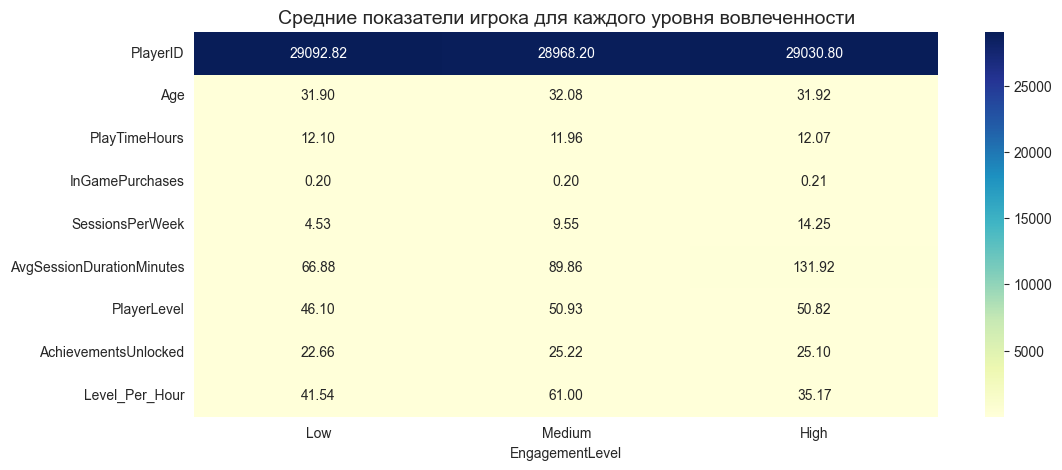

Сводная таблица:


,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,Level_Per_Hour
EngagementLevel,,,,,,,,,
Low,29092.817319,31.896939,12.104915,0.197307,4.530511,66.882119,46.101414,22.661565,41.541246
Medium,28968.201301,32.082120,11.957503,0.199752,9.553267,89.856405,50.926293,25.216424,60.997864
High,29030.803309,31.920085,12.069238,0.206463,14.254547,131.921827,50.823723,25.095975,35.172184


In [13]:
# Выбираем только числовые колонки для группировки
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Добавляем целевую переменную для группировки
group_cols = numeric_cols + ['EngagementLevel']

# Создаем сводную таблицу
profile_table = df[group_cols].groupby('EngagementLevel').mean().reindex(['Low', 'Medium', 'High'])

# Добавим визуализацию (тепловая карта по средним значениям)
plt.figure(figsize=(12, 5))
sns.heatmap(profile_table.T, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Средние показатели игрока для каждого уровня вовлеченности', fontsize=14)
plt.show()

print("Сводная таблица:")
display(profile_table)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Копируем датасет, чтобы не испортить оригинал
ml_df = df.copy()

# Удаляем ID, так как это случайное число, оно только путает модель
if 'PlayerID' in ml_df.columns:
    ml_df.drop('PlayerID', axis=1, inplace=True)

# Кодируем категориальные признаки (Gender, Location, GameGenre, GameDifficulty)
le = LabelEncoder()
cat_cols = ml_df.select_dtypes(include=['object']).columns

for col in cat_cols:
    # EngagementLevel кодируем отдельно, чтобы сохранить порядок (если нужно), 
    # но LabelEncoder тоже подойдет
    ml_df[col] = le.fit_transform(ml_df[col])

# Разделяем на признаки (X) и целевую переменную (y)
X = ml_df.drop('EngagementLevel', axis=1)
y = ml_df['EngagementLevel']

# Масштабирование (StandardScaler), чтобы Age (до 60) и PlayTime (до 1000) были в одной шкале
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделяем: 80% на обучение, 20% на проверку
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Данные готовы! Обучающая выборка: {X_train.shape}, Тестовая: {X_test.shape}")

Данные готовы! Обучающая выборка: (32027, 12), Тестовая: (8007, 12)


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Создаем и обучаем модель
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Делаем предсказание
y_pred = rf_model.predict(X_test)

# Оценка качества
print(f"Accuracy (Точность): {accuracy_score(y_test, y_pred):.2f}")
print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred))

Accuracy (Точность): 0.91

Отчет по классификации:
              precision    recall  f1-score   support

           0       0.92      0.87      0.90      2035
           1       0.91      0.87      0.89      2093
           2       0.90      0.95      0.93      3879

    accuracy                           0.91      8007
   macro avg       0.91      0.90      0.91      8007
weighted avg       0.91      0.91      0.91      8007



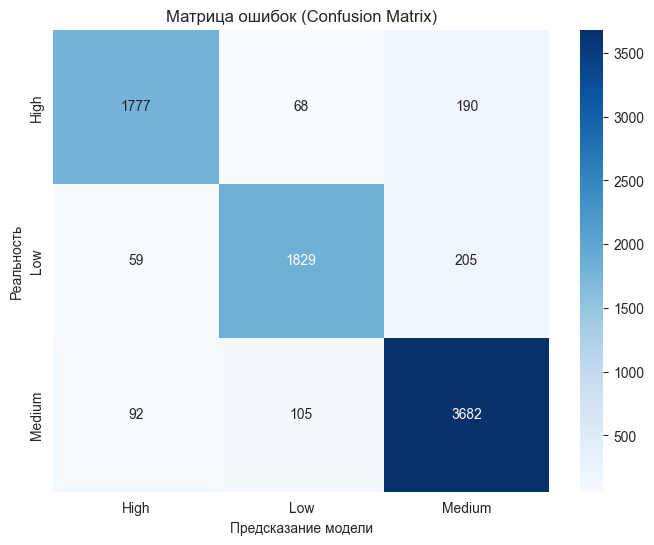

In [16]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Реальность')
plt.xlabel('Предсказание модели')
plt.show()

C:\Users\Shaim\AppData\Local\Temp\ipykernel_11692\3259391183.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


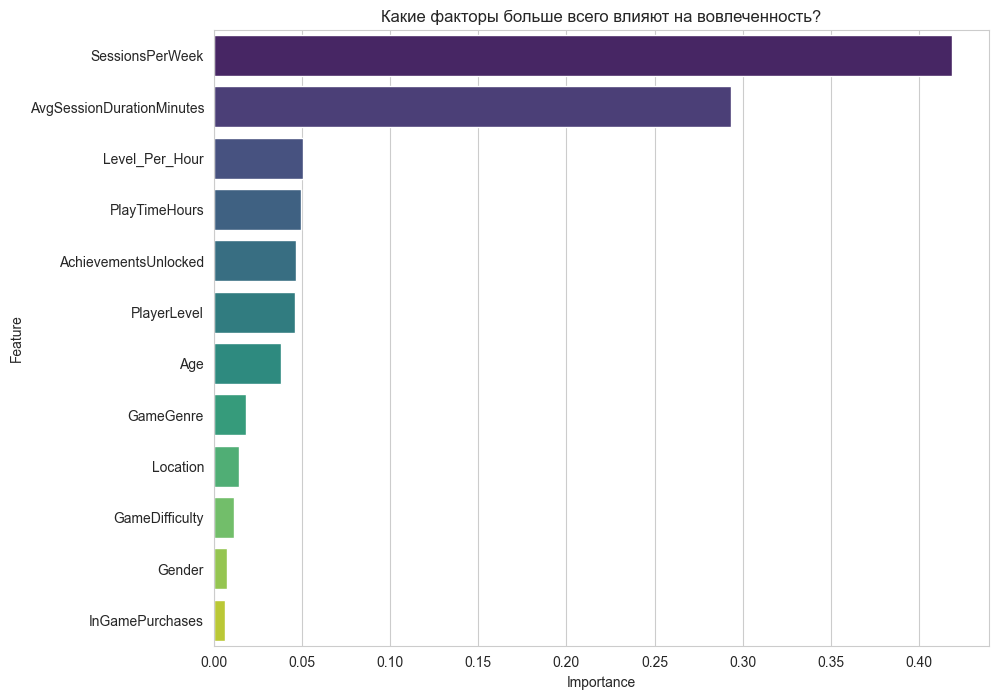

In [17]:
# Извлекаем важность признаков из модели
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Какие факторы больше всего влияют на вовлеченность?')
plt.show()

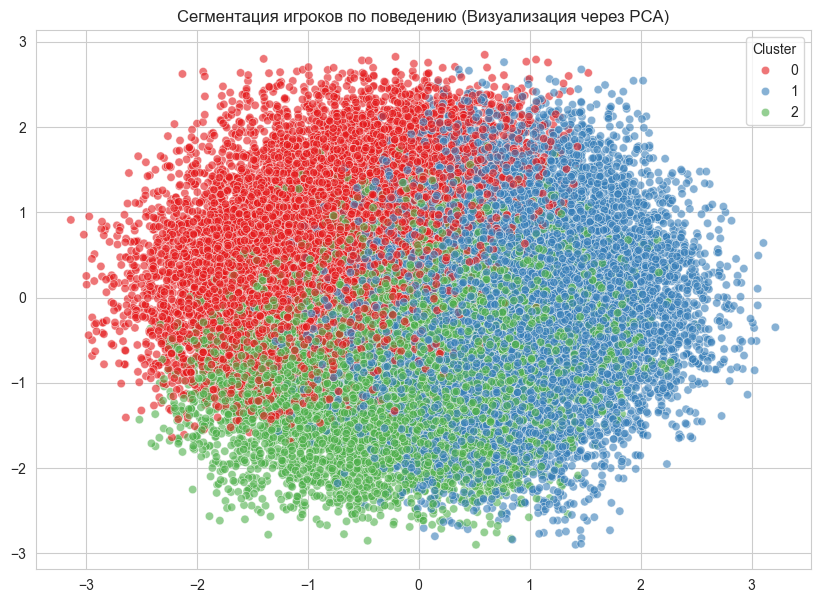

Характеристики найденных кластеров:


,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
Cluster,,,,,
0,18.592503,9.200971,92.772959,33.056917,24.914429
1,11.592203,9.556990,96.276780,79.938202,24.990518
2,5.771892,9.648668,95.092171,30.420823,23.569572


In [18]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Выбираем ключевые метрики поведения для кластеризации
behavior_features = ['PlayTimeHours', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']
X_clustering = df[behavior_features]

# Масштабируем данные (для K-means это критично)
X_clust_scaled = StandardScaler().fit_transform(X_clustering)

# Обучаем модель на 3 кластера (хотим сравнить их с Low/Medium/High)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_clust_scaled)

# Чтобы увидеть кластеры на 2D графике, используем PCA (метод главных компонент)
pca = PCA(n_components=2)
components = pca.fit_transform(X_clust_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=components[:, 0], y=components[:, 1], hue=df['Cluster'], palette='Set1', alpha=0.6)
plt.title('Сегментация игроков по поведению (Визуализация через PCA)')
plt.show()

# Смотрим средние значения для каждого найденного кластера
print("Характеристики найденных кластеров:")
display(df.groupby('Cluster')[behavior_features].mean())

In [19]:
from sklearn.linear_model import LogisticRegression

# Готовим данные, где целевая переменная - покупка
X_propensity = X_scaled # используем уже готовые отмасштабированные признаки
y_propensity = df['InGamePurchases']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_propensity, y_propensity, test_size=0.2, random_state=42)

# Используем логистическую регрессию, так как она отлично выдает вероятности
log_reg = LogisticRegression()
log_reg.fit(X_train_p, y_train_p)

# Получаем вероятность покупки (вторая колонка массива predict_proba)
df_test_probs = pd.DataFrame(X_test_p, columns=X.columns)
df_test_probs['Purchase_Probability'] = log_reg.predict_proba(X_test_p)[:, 1]

# Посмотрим на топ-5 игроков с самой высокой вероятностью покупки
print("Топ игроков по вероятности совершить покупку:")
print(df_test_probs[['Purchase_Probability']].sort_values(by='Purchase_Probability', ascending=False).head())

Топ игроков по вероятности совершить покупку:
      Purchase_Probability
7518              0.999578
2389              0.999576
5759              0.999576
7397              0.999576
5263              0.999576


In [20]:
def calculate_conditional_prob(data, condition_col, condition_val, target_col, target_val):
    # P(A|B) = P(A ∩ B) / P(B)
    prob_b = len(data[data[condition_col] == condition_val]) / len(data)
    prob_a_and_b = len(data[(data[condition_col] == condition_val) & (data[target_col] == target_val)]) / len(data)
    
    return (prob_a_and_b / prob_b) * 100

# Пример расчета
p_high_if_hard = calculate_conditional_prob(df, 'GameDifficulty', 'Hard', 'EngagementLevel', 'High')
p_high_if_easy = calculate_conditional_prob(df, 'GameDifficulty', 'Easy', 'EngagementLevel', 'High')

print(f"Вероятность High Engagement при сложной игре: {p_high_if_hard:.2f}%")
print(f"Вероятность High Engagement при легкой игре: {p_high_if_easy:.2f}%")

Вероятность High Engagement при сложной игре: 26.37%
Вероятность High Engagement при легкой игре: 25.64%


Визуализация вклада признаков для класса: Medium


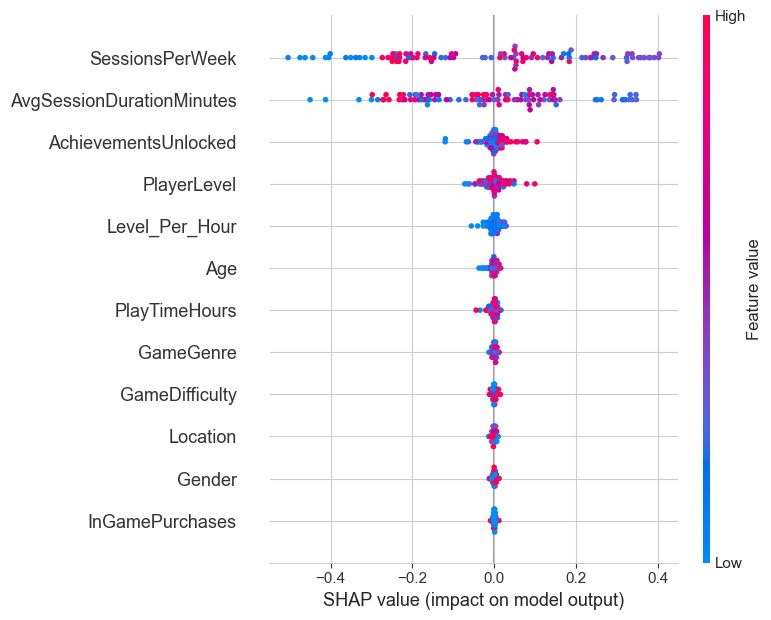

In [21]:
import shap
import numpy as np

# 1. Инициализируем эксплейнер
explainer = shap.TreeExplainer(rf_model)

# 2. Считаем значения без проверки аддитивности
shap_values = explainer.shap_values(X_test[:100], check_additivity=False)

# 3. Выбираем нужный класс (High)
# Если shap_values - это список, берем элемент. Если 3D массив - срез.
if isinstance(shap_values, list):
    class_shap_values = shap_values[2]
else:
    class_shap_values = shap_values[:, :, 2]

# 4. ВАЖНО: Приводим X_test к обычному массиву NumPy, чтобы избежать конфликтов с именами колонок
X_test_subset = X_test[:100]
if hasattr(X_test_subset, 'values'):
    X_test_subset = X_test_subset.values

# 5. Визуализация. Передаем явно имена признаков, чтобы не было ошибок
print(f"Визуализация вклада признаков для класса: {le.classes_[2]}")
shap.summary_plot(
    class_shap_values, 
    X_test_subset, 
    feature_names=X.columns.tolist(),
    plot_type="dot" # Явно указываем тип точек
)

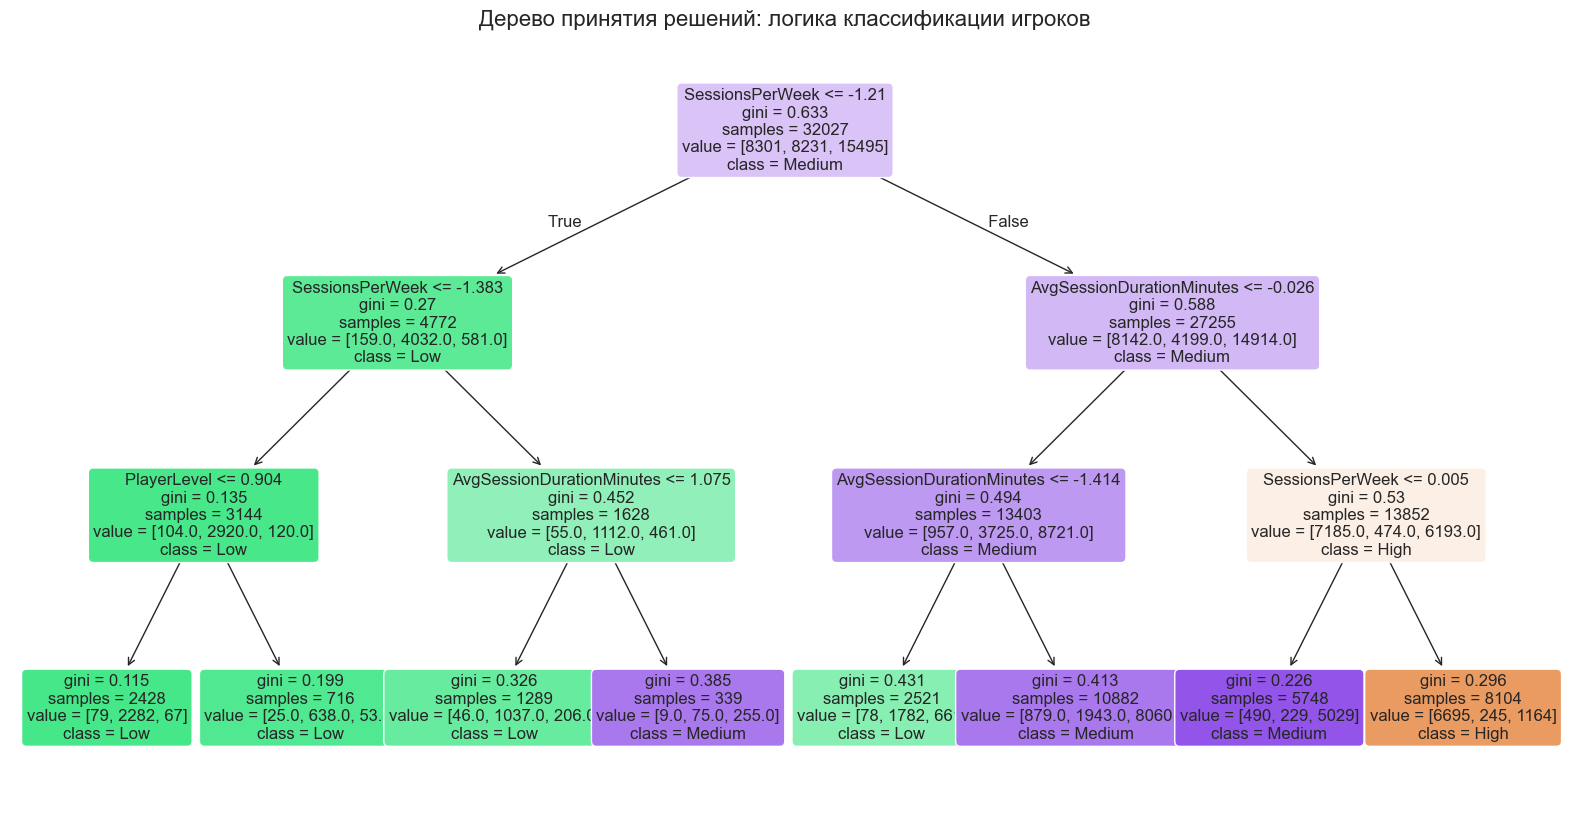

In [22]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Обучаем очень короткое дерево (глубина 3), чтобы его можно было прочитать
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(dt_model, 
          feature_names=X.columns, 
          class_names=le.classes_, 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("Дерево принятия решений: логика классификации игроков", fontsize=16)
plt.show()

In [23]:
# 1. Берем наши тестовые данные (немасштабированные для удобства манипуляций)
X_test_real = pd.DataFrame(scaler.inverse_transform(X_test), columns=X.columns)

# 2. Предсказываем текущую ситуацию
current_preds = rf_model.predict(X_test)
current_high_count = np.sum(current_preds == 2) # Предположим, 2 - это 'High'

# 3. Имитируем рост времени игры на 20%
X_test_boosted = X_test_real.copy()
X_test_boosted['PlayTimeHours'] = X_test_boosted['PlayTimeHours'] * 1.2

# 4. Масштабируем новые данные и предсказываем
X_test_boosted_scaled = scaler.transform(X_test_boosted)
new_preds = rf_model.predict(X_test_boosted_scaled)
new_high_count = np.sum(new_preds == 2)

# Результат
print(f"Текущее кол-во High-игроков в выборке: {current_high_count}")
print(f"Прогноз после увеличения времени игры на 20%: {new_high_count}")
print(f"Прогнозируемый прирост лояльности: {((new_high_count - current_high_count) / current_high_count * 100):.2f}%")

Текущее кол-во High-игроков в выборке: 4077
Прогноз после увеличения времени игры на 20%: 4069
Прогнозируемый прирост лояльности: -0.20%


In [24]:
from scipy import stats

# Разделяем данные
male_playtime = df[df['Gender'] == 'Male']['PlayTimeHours']
female_playtime = df[df['Gender'] == 'Female']['PlayTimeHours']

# Проводим t-тест (сравнение средних двух выборок)
t_stat, p_val = stats.ttest_ind(male_playtime, female_playtime)

print(f"Среднее время (Мужчины): {male_playtime.mean():.2f}")
print(f"Среднее время (Женщины): {female_playtime.mean():.2f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Результат: Различие статистически значимо. Пол влияет на время в игре.")
else:
    print("Результат: Различие НЕ значимо. Время в игре не зависит от пола.")

Среднее время (Мужчины): 12.06
Среднее время (Женщины): 11.97
P-value: 0.1925
Результат: Различие НЕ значимо. Время в игре не зависит от пола.


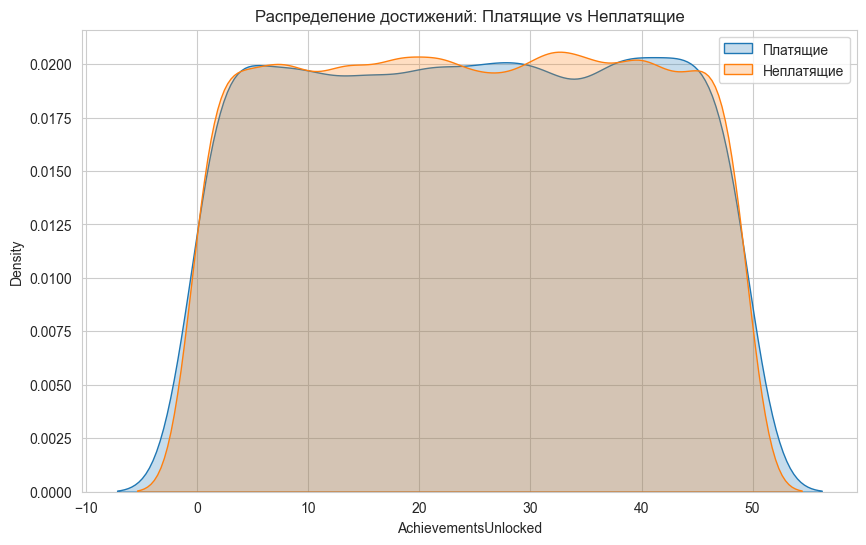

P-value (Mann-Whitney): 0.9824


In [25]:
# Разделяем на платящих и неплатящих
buyers = df[df['InGamePurchases'] == 1]['AchievementsUnlocked']
non_buyers = df[df['InGamePurchases'] == 0]['AchievementsUnlocked']

# Используем тест Манна-Уитни (он лучше подходит, если данные распределены не идеально нормально)
u_stat, p_val_mw = stats.mannwhitneyu(buyers, non_buyers)

plt.figure(figsize=(10, 6))
sns.kdeplot(buyers, label='Платящие', fill=True)
sns.kdeplot(non_buyers, label='Неплатящие', fill=True)
plt.title('Распределение достижений: Платящие vs Неплатящие')
plt.legend()
plt.show()

print(f"P-value (Mann-Whitney): {p_val_mw:.4f}")

In [26]:
# Готовим данные: создаем список выборок по каждой категории жанра
genres = df['GameGenre'].unique()
genre_samples = [df[df['GameGenre'] == g]['SessionsPerWeek'] for g in genres]

# Проводим однофакторный ANOVA
f_stat, p_val_anova = stats.f_oneway(*genre_samples)

print(f"F-статистика: {f_stat:.4f}")
print(f"P-value (ANOVA): {p_val_anova:.4f}")

if p_val_anova < 0.05:
    print("Результат: Жанр критически важен! Минимум один жанр сильно отличается от других по частоте сессий.")
    # Построим график, чтобы увидеть разницу
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='GameGenre', y='SessionsPerWeek', palette='Set3')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Результат: Жанр не имеет существенного значения для частоты заходов.")

F-статистика: 0.6539
P-value (ANOVA): 0.6241
Результат: Жанр не имеет существенного значения для частоты заходов.


In [27]:
# Для этого метода нам не нужны сложные библиотеки, сделаем на чистом pandas/scipy
# Цель: Узнать, как 'InGamePurchases' (лечение) влияет на 'PlayTimeHours' (результат)

def simple_matching_ate(df, treatment_col, outcome_col, match_cols):
    # Разделяем на тестовую (купили) и контрольную (не купили) группы
    treatment = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]
    
    effects = []
    
    # Ищем для каждого купившего "двойника" из некупивших по ключевым признакам
    # Мы упростим: сопоставим по Genre и Difficulty
    for _, treated_row in treatment.sample(100).iterrows(): # берем выборку для скорости
        match = control[
            (control['GameGenre'] == treated_row['GameGenre']) & 
            (control['GameDifficulty'] == treated_row['GameDifficulty'])
        ]
        
        if not match.empty:
            # Находим того, кто ближе всего по возрасту
            idx = (match['Age'] - treated_row['Age']).abs().idxmin()
            match_row = match.loc[idx]
            
            # Разница в часах — это локальный эффект
            effects.append(treated_row[outcome_col] - match_row[outcome_col])
            
    return np.mean(effects)

ate = simple_matching_ate(df, 'InGamePurchases', 'PlayTimeHours', ['GameGenre', 'GameDifficulty', 'Age'])
print(f"Средний причинно-следственный эффект покупки: {ate:.2f} часа.")

Средний причинно-следственный эффект покупки: -0.31 часа.


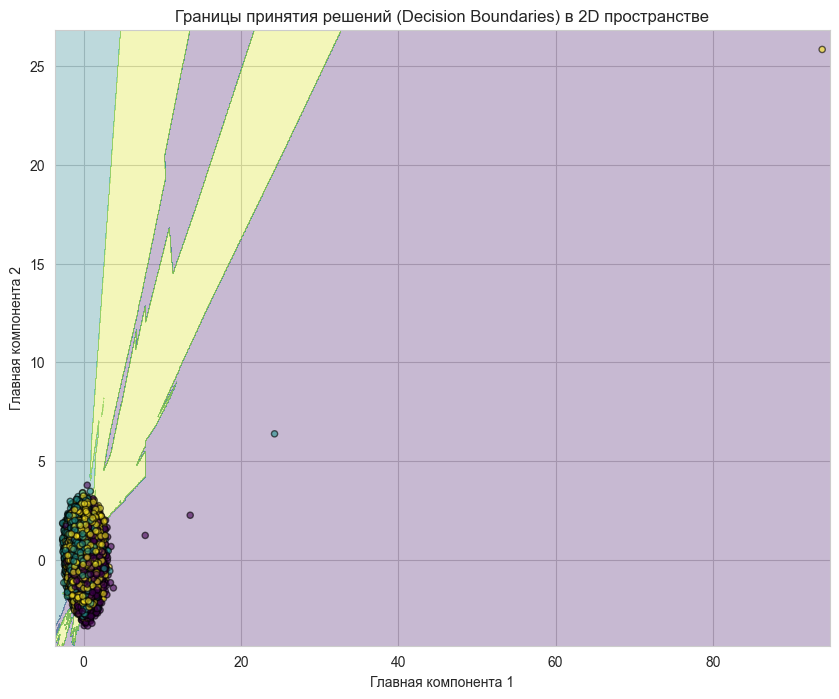

In [28]:
from matplotlib.colors import ListedColormap

# 1. Сжимаем все признаки до 2-х компонент для визуализации
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

# 2. Обучаем простую модель (SVM или К-соседей) на этих 2-х компонентах
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=15)
clf.fit(X_pca, y)

# 3. Создаем сетку точек по всей плоскости
h = .05  # шаг сетки
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 4. Предсказываем класс для каждой точки сетки
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Рисуем
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, edgecolor='k', cmap='viridis', alpha=0.6)
plt.title("Границы принятия решений (Decision Boundaries) в 2D пространстве")
plt.xlabel("Главная компонента 1")
plt.ylabel("Главная компонента 2")
plt.show()

In [29]:
from sklearn.ensemble import IsolationForest

# Обучаем модель на поиск 1% самых странных игроков
iso_forest = IsolationForest(contamination=0.01, random_state=42)
df['Is_Anomaly'] = iso_forest.fit_predict(X_scaled)

# Аномалии помечаются как -1
anomalies = df[df['Is_Anomaly'] == -1]

print(f"Найдено аномальных игроков: {len(anomalies)}")
print("Средние показатели аномальных игроков по сравнению с обычными:")
comparison = pd.DataFrame({
    'Normal': df[df['Is_Anomaly'] == 1].mean(numeric_only=True),
    'Anomaly': anomalies.mean(numeric_only=True)
})
display(comparison)

Найдено аномальных игроков: 401
Средние показатели аномальных игроков по сравнению с обычными:


,Normal,Anomaly
PlayerID,29011.206570,29539.678304
Age,32.000580,31.197007
PlayTimeHours,12.120196,2.552913
InGamePurchases,0.196755,0.605985
SessionsPerWeek,9.462519,10.386534
AvgSessionDurationMinutes,94.844397,89.638404
PlayerLevel,49.508061,64.234414
AchievementsUnlocked,24.546312,22.566085
Level_Per_Hour,12.475413,3690.139835
Cluster,0.986325,1.396509


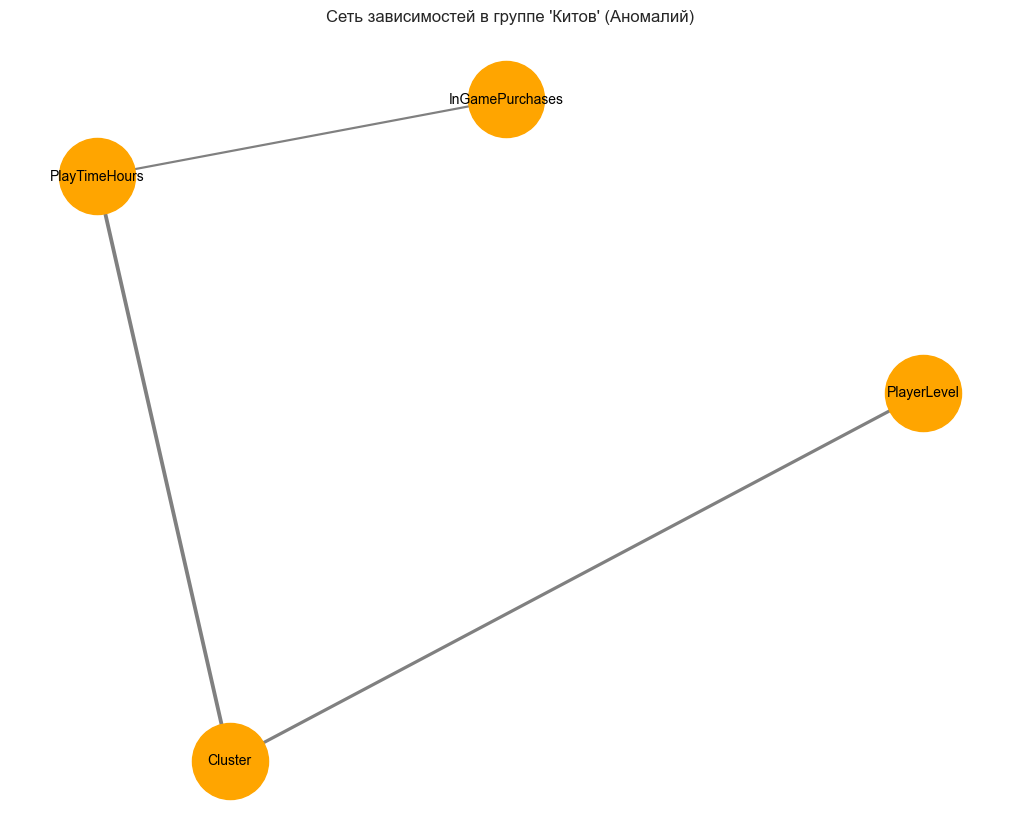

In [30]:
import networkx as nx

# Берем только аномальных игроков
anomaly_data = df[df['Is_Anomaly'] == -1].select_dtypes(include=[np.number])

# Считаем корреляцию
corr_matrix = anomaly_data.corr()

# Создаем граф
G = nx.Graph()

# Добавляем ребра, если корреляция выше порога (например, 0.2)
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.2:
            G.add_edge(corr_matrix.columns[i], corr_matrix.columns[j], 
                       weight=corr_matrix.iloc[i, j])

# Рисуем
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=1.5)  # Алгоритм расположения узлов

# Толщина линий зависит от силы корреляции
weights = [G[u][v]['weight'] * 5 for u, v in G.edges()]

nx.draw(G, pos, with_labels=True, node_color='orange', 
        node_size=3000, font_size=10, width=weights, edge_color='gray')

plt.title("Сеть зависимостей в группе 'Китов' (Аномалий)")
plt.show()

R^2 Score прогноза ценности: 0.3452


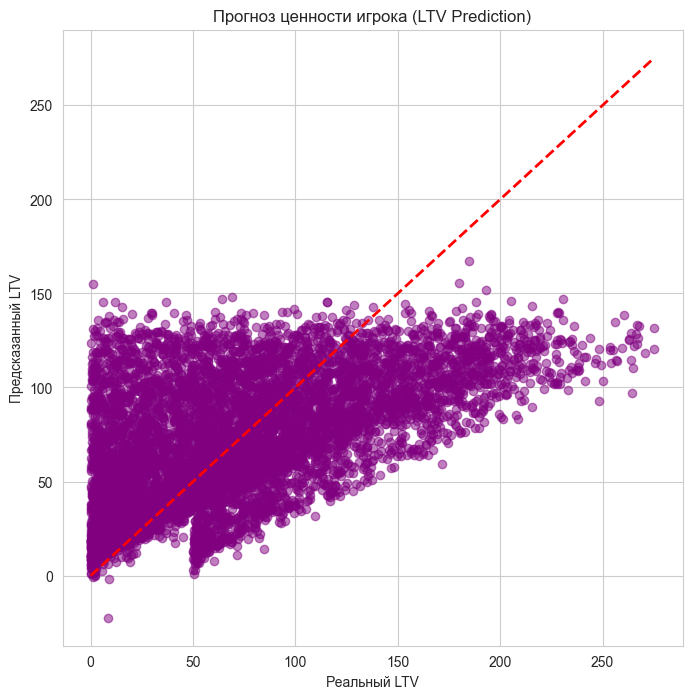

In [31]:
from sklearn.ensemble import GradientBoostingRegressor

# 1. Генерируем целевую метрику LTV (синтетическая оценка доходности)
# Формула: (Покупки * 50) + (Часы игры * Уровень / 10)
df['LTV'] = (df['InGamePurchases'] * 50) + (df['PlayTimeHours'] * df['PlayerLevel'] / 10)

# 2. Готовим признаки (убираем всё, что связано с формулой LTV, чтобы не было утечки)
X_ltv = X.drop(['PlayTimeHours', 'PlayerLevel', 'InGamePurchases'], axis=1, errors='ignore')
y_ltv = df['LTV']

# 3. Обучаем мощный градиентный бустинг
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_ltv, y_ltv, test_size=0.2, random_state=42)
gbm = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5)
gbm.fit(X_train_l, y_train_l)

# 4. Проверяем точность
print(f"R^2 Score прогноза ценности: {gbm.score(X_test_l, y_test_l):.4f}")

# 5. Сравниваем реальный LTV и предсказанный
plt.figure(figsize=(8, 8))
plt.scatter(y_test_l, gm_preds := gbm.predict(X_test_l), alpha=0.5, color='purple')
plt.plot([y_test_l.min(), y_test_l.max()], [y_test_l.min(), y_test_l.max()], 'r--', lw=2)
plt.xlabel('Реальный LTV')
plt.ylabel('Предсказанный LTV')
plt.title('Прогноз ценности игрока (LTV Prediction)')
plt.show()